## Evaluating segmentation performance!

We choose well B02 from donor 287, tri-culture to evaluate the performance of a few segmentation algorithms. "Ground-truth" is provided from hand-labelled nuclear masks (15/test/labels/B02.tif).

**Precision** = Of all the ones we guessed (TP+FP), how many are TP?


**Recall** = Of all the ones that are actually positive (TP+FN), how many are TP?

In [154]:
import tifffile
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.DataFrame(index=['IOU', 'F1', 'MCC', 'Precision', 'Recall'])

# LABELS

labels_file = '/home/jdweiss1/orcd/scratch/15/test/labels/B02.tif'
labels = tifffile.imread(labels_file)

# multi-class --> binary classification
labels_2d = (labels > 0)
labels = labels_2d.flatten().astype(int)


# DATA

measurements = pd.read_csv('../15/test/all_wells_measurements.csv')

In [155]:
def update_df(model, preds):

    iou       = metrics.jaccard_score(labels, preds)
    f1        = metrics.f1_score(labels, preds)
    mcc       = metrics.matthews_corrcoef(labels, preds)
    precision = metrics.precision_score(labels, preds)
    recall    = metrics.recall_score(labels, preds)

    df[model] = [iou, f1, mcc, precision, recall]


def confusion_matrix(model, preds):

    display = metrics.ConfusionMatrixDisplay.from_predictions(
        labels, preds, cmap=plt.cm.Blues
    )
    display.ax_.set_title(f'{model} Confusion Matrix')


def curves(model, preds):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # precision-recall curve
    _ = metrics.PrecisionRecallDisplay.from_predictions(
        labels, preds, name=model, plot_chance_level=True, despine=True, ax=ax1
    )
    ax1.set_title('Precision-Recall Curve')
    ax1.set_xlabel('Recall')
    ax1.set_ylabel('Precision')

    # ROC curve
    _ = metrics.RocCurveDisplay.from_predictions(
        labels, preds, name=model, plot_chance_level=True, despine=True, ax=ax2
    )
    ax2.set_title('ROC Curve')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')

    fig.suptitle('Cellpose2 Performance on 287-tri/B02')
    plt.tight_layout()
    plt.show()


def get_error_map(preds_2d, filepath):
    error_map = np.zeros((*preds_2d.shape, 3))

    tp = labels_2d  &  preds_2d
    fp = ~labels_2d &  preds_2d
    fn = labels_2d  & ~preds_2d

    error_map = np.zeros((*preds_2d.shape, 3), dtype=np.float32)
    error_map[tp] = [0, 1, 0]   # TP -- green
    error_map[fp] = [1, 0, 0]   # FP -- red
    error_map[fn] = [0, 0, 1]   # FN -- blue

    tifffile.imwrite(filepath, error_map)

### Cellpose v2

In [156]:
# PREDICTIONS

preds_file = '/home/jdweiss1/orcd/scratch/15/287-tri/masks/B02_nuclear_masks.tif'
preds = tifffile.imread(preds_file)

# take the max intensity projection of the predicted nuclear masks
preds = preds.max(axis=0)

# multi-class --> binary classification
preds_2d = (preds > 0)
preds = preds_2d.flatten().astype(int)

In [157]:
update_df('Cellposev2', preds)
df

,Cellposev2
IOU,0.596796
F1,0.747492
MCC,0.710920
Precision,0.676455
Recall,0.835200


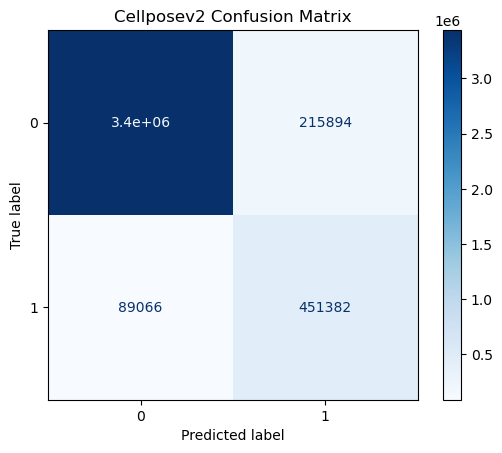

In [158]:
confusion_matrix('Cellposev2', preds)

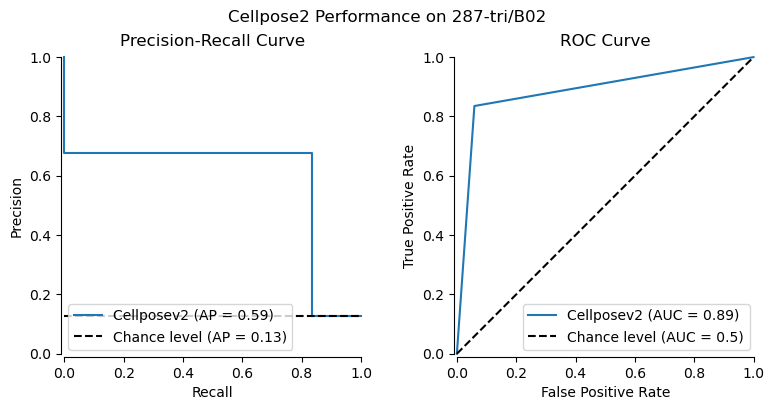

In [159]:
curves('Cellposev2', preds)

High recall, low precision indicates that Cellpose2 is over-segmenting (bleeding into background). I have a hunch that this happens in areas of dense nuclei w/ high overall intensity & bleeding.

In [160]:
get_error_map(preds_2d, 'figs/error_map.tif')

In [161]:
measurements['centroid_x'] = measurements['centroid_x_um'] / 0.6793
measurements['centroid_y'] = measurements['centroid_y_um'] / 0.6793
measurements['centroid_z'] = measurements['centroid_z_um'] / 5


Text(0.5, 1.0, 'Labels 1')

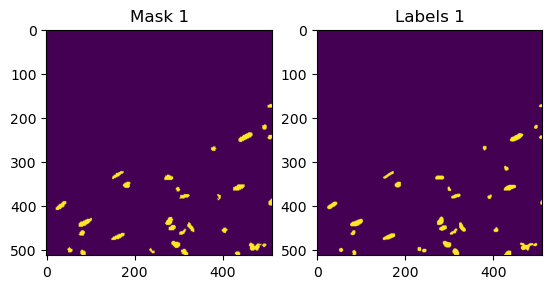

In [162]:
mask_1 = preds_2d[0:512, 0:512]

labels_1 = labels_2d[0:512, 0:512]

_, (ax1, ax2) = plt.subplots(1,2)
ax1.imshow(mask_1)
ax1.set_title('Mask 1')
ax2.imshow(labels_1)
ax2.set_title('Labels 1')


/home/jdweiss1/.conda/envs/cellpose2/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Jaccard is ill-defined and being set to 0.0 due to no true or predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jdweiss1/.conda/envs/cellpose2/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Text(0, 0.5, 'F1')

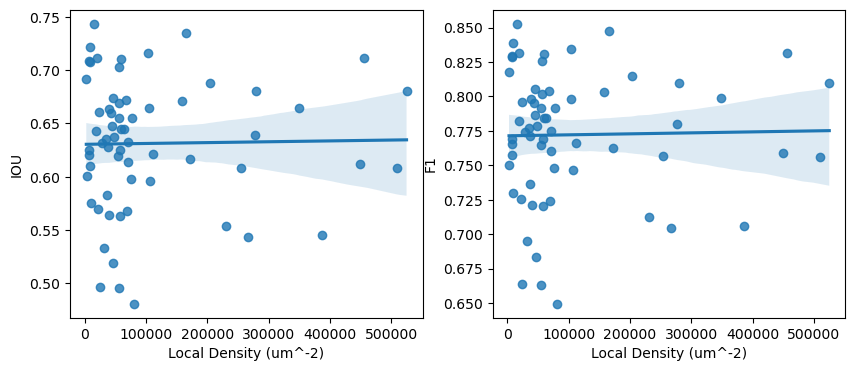

In [176]:
# split image into smaller regions, evaluate performance, plot performance vs cell density in region

x, y = preds_2d.shape # (2048, 2048)
grid = 8
patch_size = x // grid # 512
xy_pixel_um = 0.6793

data = {
    'IOU': [],
    'F1': [],
    'density': [],
    'EpCAM': [],
    'DAPI': [],
}

for i in range(grid):

    for j in range(grid):

        lower_x = i*patch_size
        upper_x = lower_x + patch_size

        lower_y = j*patch_size
        upper_y = lower_y + patch_size

        mini_mask_2d = preds_2d[lower_x:upper_x, lower_y:upper_y]
        mini_mask = (mini_mask_2d > 0).flatten().astype(int)

        mini_labels_2d = labels_2d[lower_x:upper_x, lower_y:upper_y]
        mini_labels = (mini_labels_2d > 0).flatten().astype(int)

        iou = metrics.jaccard_score(mini_labels, mini_mask)
        f1 = metrics.f1_score(mini_labels, mini_mask)

        # NOTE: cell counts are calculated from segmentation output, not hand-labeled data. it's way easier this way,
        #       but there's potential information leakage. what if the segmentation is under-classifying, affecting
        #       both the F1/IOU score *and* the density measurement?
        roi_mask = ((measurements['centroid_x'] >= lower_x) & (measurements['centroid_x'] < upper_x) &
                    (measurements['centroid_y'] >= lower_y) & (measurements['centroid_y'] < upper_y))

        num_nuclei = roi_mask.sum()
        region_area = (patch_size * xy_pixel_um) ** 2
        region_density = num_nuclei / region_area

        epcam = measurements['channel_5_nuclear_max'][roi_mask].sum()
        dapi = measurements['channel_1_nuclear_max'][roi_mask].sum()

        data['IOU'].append(iou)
        data['F1'].append(f1)
        data['density'].append(region_density)
        data['EpCAM'].append(epcam)
        data['DAPI'].append(dapi)


density_df = pd.DataFrame(data, index=list(range(grid ** 2)))
density_df = density_df[density_df['density'] != 0]

_, axs = plt.subplots(1, 2, figsize=(10,4))

sns.regplot(density_df, x='EpCAM', y='IOU', ax=axs[0])
axs[0].set_xlabel('Local Density (um^-2)')
axs[0].set_ylabel('IOU')

sns.regplot(density_df, x='EpCAM', y='F1', ax=axs[1])
axs[1].set_xlabel('Local Density (um^-2)')
axs[1].set_ylabel('F1')

Nope! Seems like density doesn't have much to do with it. Other stuff to look into:
- how does the classification do across z-stack depth?
- do the cytoplasm masks encompass all the intensity that is *likely* associated with the cell?